***STEP 1 — Import Libraries***

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("Libraries imported successfully")

Libraries imported successfully


***STEP 2 — LOAD DATASET***

In [4]:
df = pd.read_excel(r"C:\Users\JayanthJella\Downloads\Bike_rental_demand.xlsx")
print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (1200, 17)


,record_id,date,season,year,month,hour,is_holiday,day_of_week,is_working_day,weather_condition,temperature,feels_like_temperature,humidity,wind_speed,casual_rentals,registered_rentals,total_rentals
0,1,2024-01-06,1,0,1,21,0,5,0,2,0.2919,0.3223,0.7297,0.2375,27,39,66
1,2,2024-02-16,1,0,2,11,0,4,1,2,0.5623,0.5498,0.7538,0.1170,30,77,107
2,3,2024-02-09,1,0,2,23,0,4,1,2,0.3348,0.3449,0.7852,0.1876,26,67,93
3,4,2024-01-27,1,0,1,18,0,5,0,3,0.3894,0.3948,0.6945,0.0932,68,119,187
4,5,2024-01-26,1,0,1,15,0,4,1,2,0.3912,0.2951,0.6997,0.2747,70,202,272


***STEP 3 — Data Preprocessing***

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)


Number of rows: 1200
Number of columns: 17

Data Types:
record_id                          int64
date                      datetime64[us]
season                             int64
year                               int64
month                              int64
hour                               int64
is_holiday                         int64
day_of_week                        int64
is_working_day                     int64
weather_condition                  int64
temperature                      float64
feels_like_temperature           float64
humidity                         float64
wind_speed                       float64
casual_rentals                     int64
registered_rentals                 int64
total_rentals                      int64
dtype: object


In [6]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
record_id                 0
date                      0
season                    0
year                      0
month                     0
hour                      0
is_holiday                0
day_of_week               0
is_working_day            0
weather_condition         0
temperature               0
feels_like_temperature    0
humidity                  0
wind_speed                0
casual_rentals            0
registered_rentals        0
total_rentals             0
dtype: int64


In [7]:
print("\nDuplicate Records:")
print(df.duplicated().sum())


Duplicate Records:
0


In [8]:
df["date"] = pd.to_datetime(df["date"])

print(df.dtypes)

record_id                          int64
date                      datetime64[us]
season                             int64
year                               int64
month                              int64
hour                               int64
is_holiday                         int64
day_of_week                        int64
is_working_day                     int64
weather_condition                  int64
temperature                      float64
feels_like_temperature           float64
humidity                         float64
wind_speed                       float64
casual_rentals                     int64
registered_rentals                 int64
total_rentals                      int64
dtype: object


In [9]:
missing_values = df.isnull().sum()

print("Missing values:")
display(missing_values[missing_values > 0])


Missing values:


Series([], dtype: int64)

In [10]:
display(df.describe())

,record_id,date,season,year,month,hour,is_holiday,day_of_week,is_working_day,weather_condition,temperature,feels_like_temperature,humidity,wind_speed,casual_rentals,registered_rentals,total_rentals
count,1200.000000,1200,1200.0,1200.0,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,600.500000,2024-01-30 18:07:12,1.0,0.0,1.490833,11.419167,0.033333,2.863333,0.735000,1.660000,0.396985,0.397841,0.733197,0.217173,46.609167,107.948333,154.557500
min,1.000000,2024-01-01 00:00:00,1.0,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.057500,0.051400,0.417600,0.000000,0.000000,0.000000,0.000000
25%,300.750000,2024-01-16 00:00:00,1.0,0.0,1.000000,5.000000,0.000000,1.000000,0.000000,1.000000,0.314475,0.312675,0.666775,0.158975,16.000000,35.000000,52.000000
50%,600.500000,2024-01-31 00:00:00,1.0,0.0,1.000000,11.000000,0.000000,3.000000,1.000000,1.000000,0.396600,0.400900,0.727300,0.215000,43.000000,95.000000,141.500000
75%,900.250000,2024-02-15 00:00:00,1.0,0.0,2.000000,17.000000,0.000000,5.000000,1.000000,2.000000,0.481500,0.484900,0.803050,0.274625,72.000000,167.000000,240.000000
max,1200.000000,2024-02-29 00:00:00,1.0,0.0,2.000000,23.000000,1.000000,6.000000,1.000000,4.000000,0.735300,0.745100,1.000000,0.582300,168.000000,336.000000,471.000000
std,346.554469,NaN,0.0,0.0,0.500124,6.965072,0.179580,1.996575,0.441517,0.816469,0.114268,0.119690,0.102949,0.086566,34.653482,80.491727,112.600433


In [11]:
numeric_columns = df.select_dtypes(include="number").columns

***STEP 4 — TARGET VARIABLE ANALYSIS***

Target variable: total_rentals

Target Statistics:
count    1200.000000
mean      154.557500
std       112.600433
min         0.000000
25%        52.000000
50%       141.500000
75%       240.000000
max       471.000000
Name: total_rentals, dtype: float64


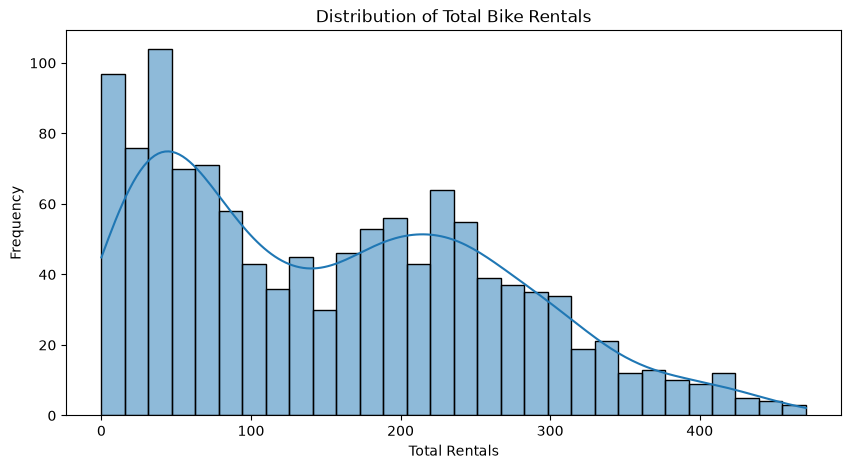

In [12]:
print("Target variable: total_rentals")

print("\nTarget Statistics:")
print(df["total_rentals"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(
    df["total_rentals"],
    bins=30,
    kde=True
)
plt.title("Distribution of Total Bike Rentals")
plt.xlabel("Total Rentals")
plt.ylabel("Frequency")

plt.show()

***STEP 5 — FEATURE ENGINEERING FROM DATE***

In [13]:
df["day"] = df["date"].dt.day

df["month_from_date"] = df["date"].dt.month

df["day_of_week_from_date"] = df["date"].dt.dayofweek

# Weekend indicator

df["is_weekend"] = (
    df["day_of_week_from_date"] >= 5
).astype(int)

print("Feature engineering completed.")

display(
    df[
        [
            "date",
            "day",
            "month_from_date",
            "day_of_week_from_date",
            "is_weekend"
        ]
    ].head()
)

Feature engineering completed.


,date,day,month_from_date,day_of_week_from_date,is_weekend
0,2024-01-06,6,1,5,1
1,2024-02-16,16,2,4,0
2,2024-02-09,9,2,4,0
3,2024-01-27,27,1,5,1
4,2024-01-26,26,1,4,0


***STEP 6 — EXPLORATORY DATA ANALYSIS***

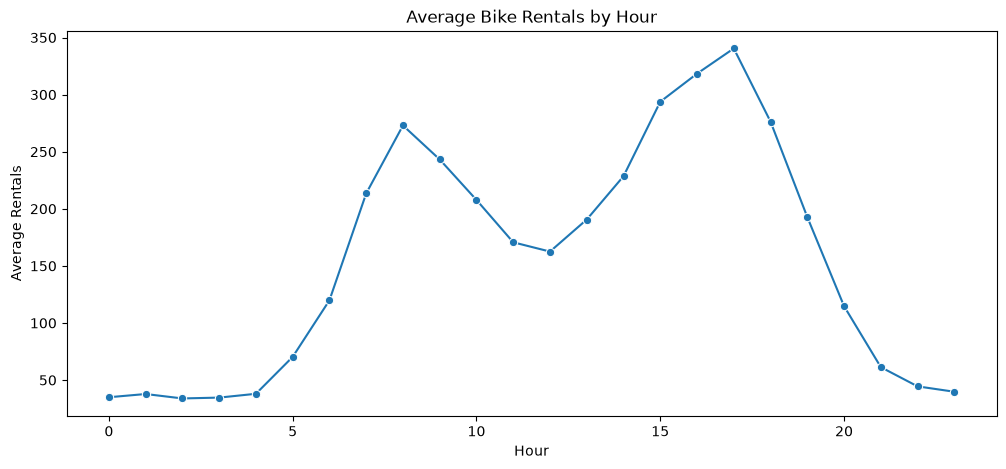

In [14]:
hourly_demand = (
    df.groupby("hour")["total_rentals"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=hourly_demand,
    x="hour",
    y="total_rentals",
    marker="o"
)
plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")

plt.show()

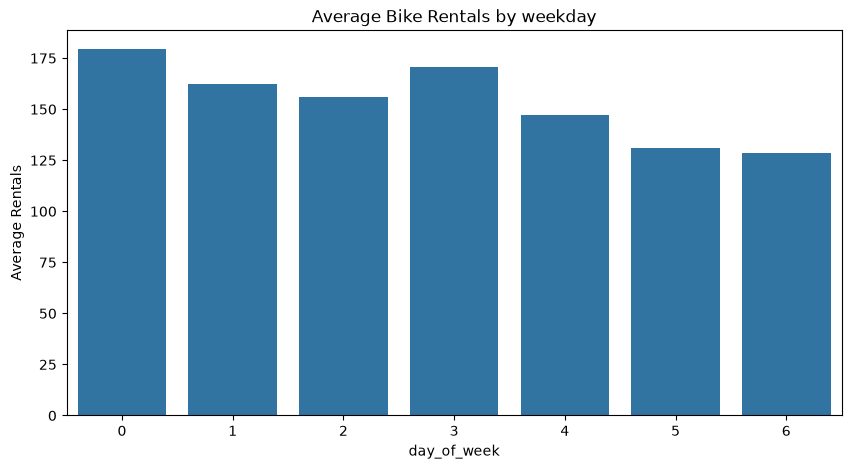

In [15]:
daily_demand = (
    df.groupby("day_of_week")["total_rentals"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=daily_demand,
    x="day_of_week",
    y="total_rentals"
)

plt.title("Average Bike Rentals by weekday")
plt.xlabel("day_of_week")
plt.ylabel("Average Rentals")

plt.show()

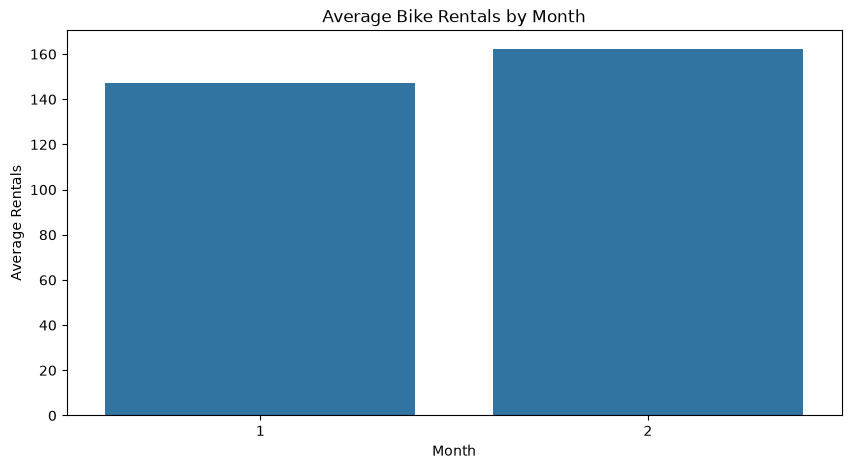

In [16]:
monthly_demand = (
    df.groupby("month")["total_rentals"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=monthly_demand,
    x="month",
    y="total_rentals"
)

plt.title("Average Bike Rentals by Month")
plt.xlabel("Month")
plt.ylabel("Average Rentals")

plt.show()

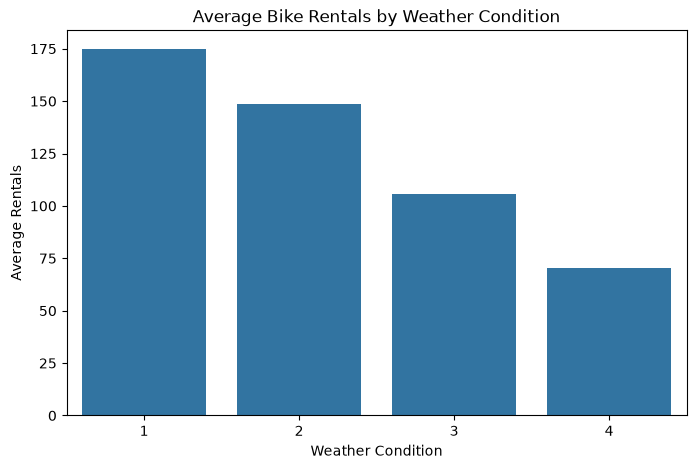

In [17]:
weather_demand = (
    df.groupby("weather_condition")["total_rentals"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=weather_demand,
    x="weather_condition",
    y="total_rentals"
)

plt.title("Average Bike Rentals by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Rentals")

plt.show()


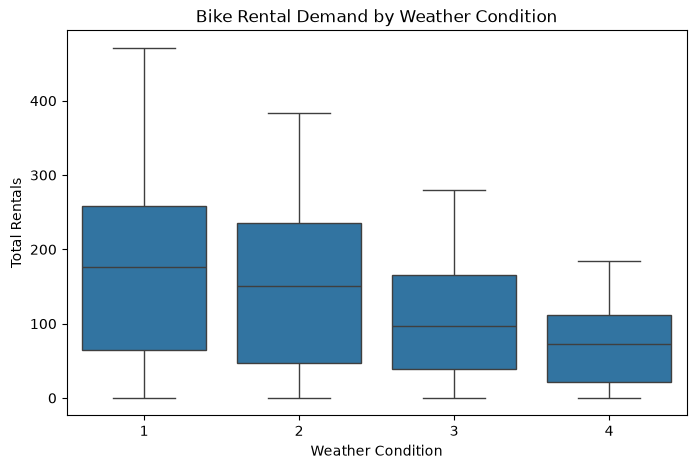

In [49]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="weather_condition",
    y="total_rentals"
)

plt.title("Bike Rental Demand by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Total Rentals")
plt.show()

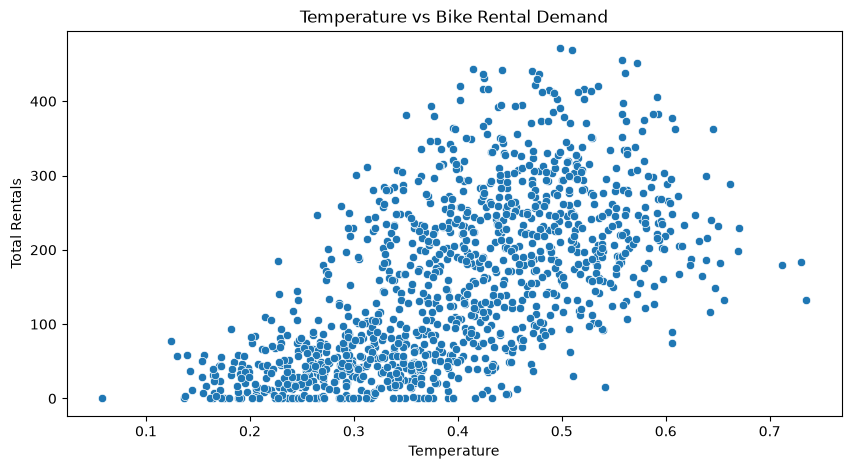

In [18]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="temperature",
    y="total_rentals"
)

plt.title("Temperature vs Bike Rental Demand")
plt.xlabel("Temperature")
plt.ylabel("Total Rentals")

plt.show()

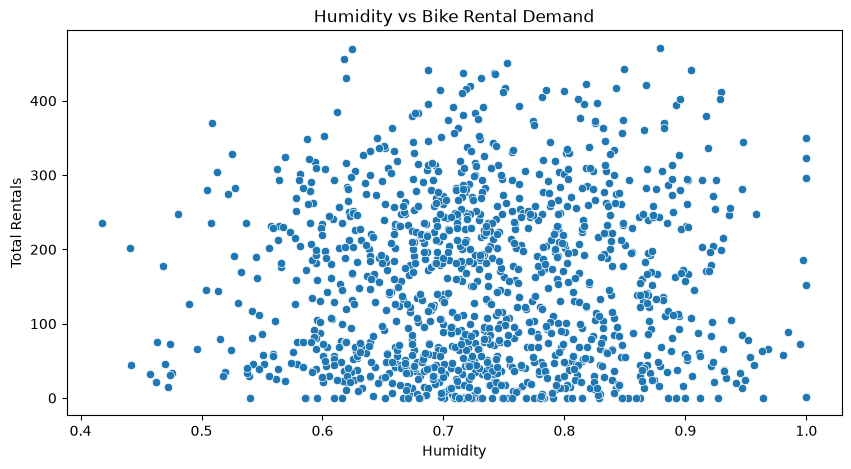

In [19]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="humidity",
    y="total_rentals"
)

plt.title("Humidity vs Bike Rental Demand")
plt.xlabel("Humidity")
plt.ylabel("Total Rentals")

plt.show()

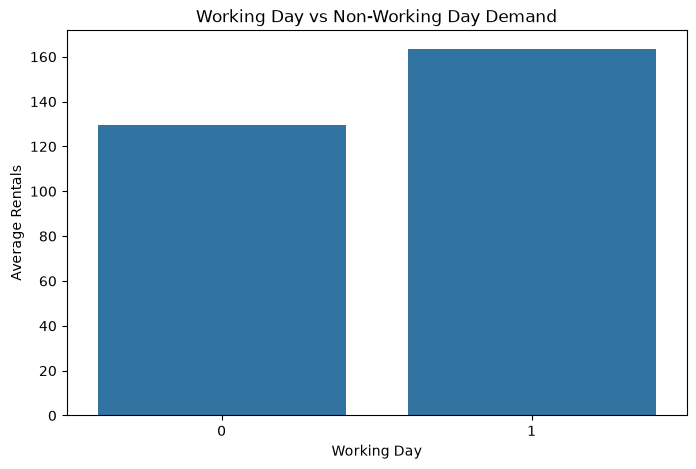

In [20]:
workingday_demand = (
    df.groupby("is_working_day")["total_rentals"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=workingday_demand,
    x="is_working_day",
    y="total_rentals"
)

plt.title("Working Day vs Non-Working Day Demand")
plt.xlabel("Working Day")
plt.ylabel("Average Rentals")

plt.show()

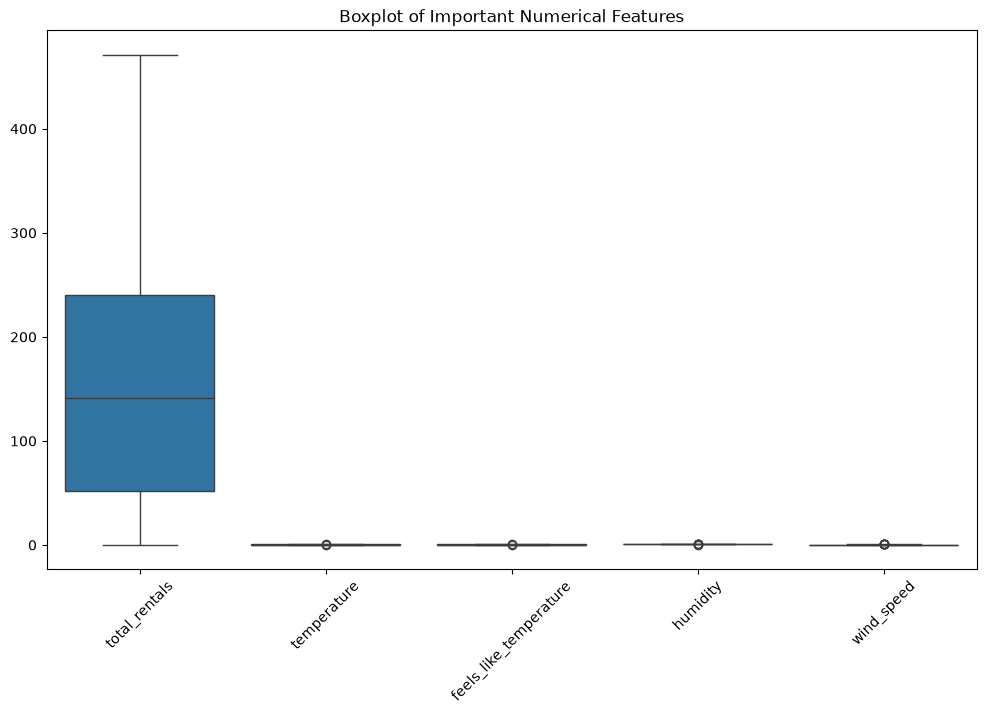

In [21]:
important_numeric_features = [
    "total_rentals",
    "temperature",
    "feels_like_temperature",
    "humidity",
    "wind_speed"
]

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df[important_numeric_features]
)

plt.title("Boxplot of Important Numerical Features")

plt.xticks(rotation=45)

plt.show()


In [22]:
target_correlation = (
    df[numeric_columns]
    .corr()["total_rentals"]
    .sort_values(ascending=False)
)

print("Correlation with total_rentals:")

display(target_correlation)

Correlation with total_rentals:


total_rentals             1.000000
registered_rentals        0.990627
casual_rentals            0.948335
temperature               0.608322
feels_like_temperature    0.579058
hour                      0.264089
is_working_day            0.132922
month                     0.067914
humidity                  0.037595
record_id                 0.012660
wind_speed                0.007692
is_holiday               -0.034205
day_of_week              -0.141896
weather_condition        -0.242489
season                         NaN
year                           NaN
Name: total_rentals, dtype: float64

In [23]:
df = df.sort_values(
    by=["date", "hour"]
).reset_index(drop=True)

In [25]:
features = [
    "year",
    "month",
    "hour",
    "day_of_week",
    "is_holiday",
    "is_working_day",
    "is_weekend",
    "season",
    "weather_condition",
    "temperature",
    "feels_like_temperature",
    "humidity",
    "wind_speed"
]

##### I've removed casual_rentals and registered_rentals from features because they directly add up to total_rentals. Including them would leak information about the target into the model.

***Step-7 Feature Selection & Target Definition***

In [42]:
target = "total_rentals"

X = df[features]

y = df[target]

print("X shape:", X.shape)

print("y shape:", y.shape)


X shape: (1200, 13)
y shape: (1200,)


In [27]:

display(X.head())

display(y.head())

,year,month,hour,day_of_week,is_holiday,is_working_day,is_weekend,season,weather_condition,temperature,feels_like_temperature,humidity,wind_speed
0,0,1,2,0,0,1,0,1,1,0.0575,0.0899,0.7796,0.1816
1,0,1,3,0,0,1,0,1,1,0.3184,0.3703,0.9804,0.3541
2,0,1,5,0,0,1,0,1,1,0.4126,0.3709,0.8143,0.1936
3,0,1,6,0,0,1,0,1,1,0.3711,0.4280,0.8123,0.0227
4,0,1,6,0,0,1,0,1,1,0.3715,0.4117,0.7946,0.3187


0      0
1     58
2     94
3    129
4    153
Name: total_rentals, dtype: int64

***Step 8 — Train-Test Split***

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.20,random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (960, 13)
Testing data: (240, 13)


***Step 9 — Model Building***

In [29]:
#Linear Regression
linear_model = LinearRegression()
linear_model.fit(
    X_train,
    y_train
)
linear_prediction = linear_model.predict(
    X_test
)
print("Linear Regression completed")


Linear Regression completed


In [30]:
#Decision Tree
decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

decision_tree_prediction = decision_tree.predict(
    X_test
)

print("Decision Tree completed")


Decision Tree completed


In [31]:
#Random Forest
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

random_forest_prediction = random_forest.predict(
    X_test
)

print("Random Forest completed")

Random Forest completed


***Step 10 — Model Evaluation***

In [32]:
linear_mae = mean_absolute_error(
    y_test,
    linear_prediction
)

linear_mse = mean_squared_error(
    y_test,
    linear_prediction
)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(
    y_test,
    linear_prediction
)


decision_mae = mean_absolute_error(
    y_test,
    decision_tree_prediction
)

decision_mse = mean_squared_error(
    y_test,
    decision_tree_prediction
)

decision_rmse = np.sqrt(decision_mse)

decision_r2 = r2_score(
    y_test,
    decision_tree_prediction
)


random_mae = mean_absolute_error(
    y_test,
    random_forest_prediction
)

random_mse = mean_squared_error(
    y_test,
    random_forest_prediction
)

random_rmse = np.sqrt(random_mse)

random_r2 = r2_score(
    y_test,
    random_forest_prediction
)

In [33]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE": [
        linear_mae,
        decision_mae,
        random_mae
    ],

    "RMSE": [
        linear_rmse,
        decision_rmse,
        random_rmse
    ],

    "R2": [
        linear_r2,
        decision_r2,
        random_r2
    ]
})

display(results.round(2))

,Model,MAE,RMSE,R2
0,Linear Regression,63.57,79.09,0.55
1,Decision Tree,38.51,47.67,0.84
2,Random Forest,28.83,36.88,0.90


***Step 11 — Model Comparison***

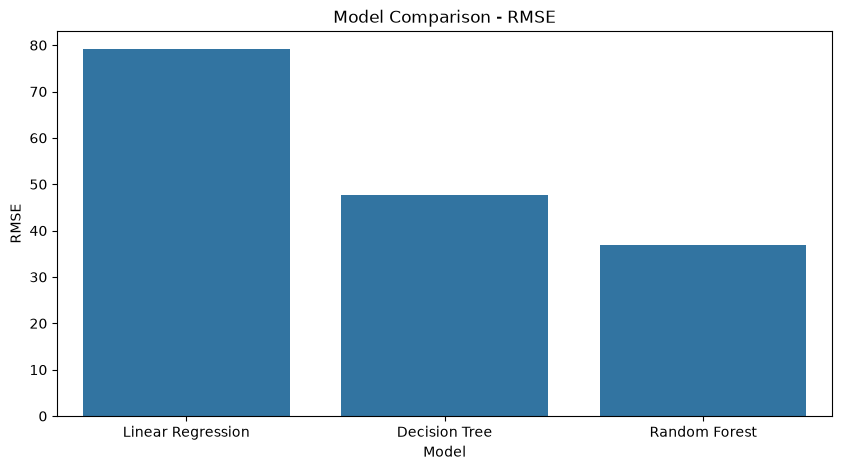

In [34]:
# Model Comparison

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)
plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

#### Lower RMSE is better.

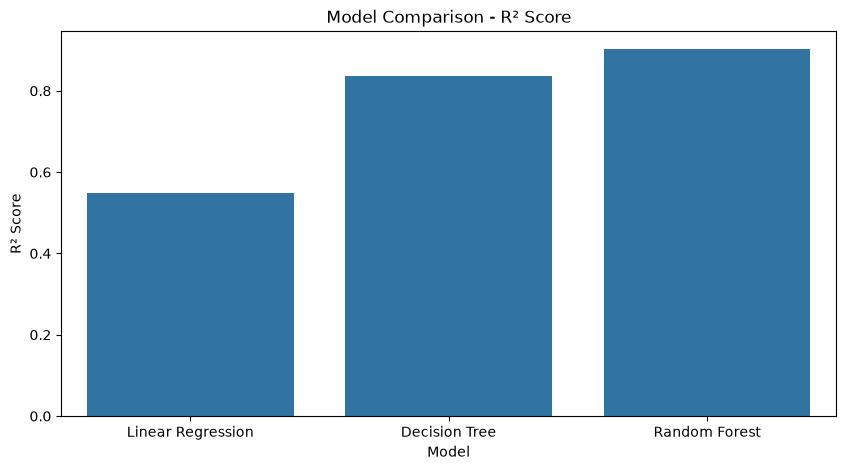

In [35]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="R2"
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()

### Higher R² is better.

In [36]:
best_rmse_model = results.loc[
    results["RMSE"].idxmin(),
    "Model"
]

best_r2_model = results.loc[
    results["R2"].idxmax(),
    "Model"
]

best_mae_model = results.loc[
    results["MAE"].idxmin(),
    "Model"
]

print("Lowest RMSE:", best_rmse_model)
print("Highest R²:", best_r2_model)
print("Lowest MAE:", best_mae_model)

Lowest RMSE: Random Forest
Highest R²: Random Forest
Lowest MAE: Random Forest


In [37]:
print("====================================")
print("      BIKE RENTAL DEMAND MODEL")
print("            CONCLUSION")
print("====================================")

print("\nModel Comparison:")
display(results.round(2))

print("\nLowest RMSE:", best_rmse_model)
print("Highest R²:", best_r2_model)
print("Lowest MAE:", best_mae_model)

      BIKE RENTAL DEMAND MODEL
            CONCLUSION

Model Comparison:


,Model,MAE,RMSE,R2
0,Linear Regression,63.57,79.09,0.55
1,Decision Tree,38.51,47.67,0.84
2,Random Forest,28.83,36.88,0.90



Lowest RMSE: Random Forest
Highest R²: Random Forest
Lowest MAE: Random Forest


***Step 12 — Feature Importance Analysis***

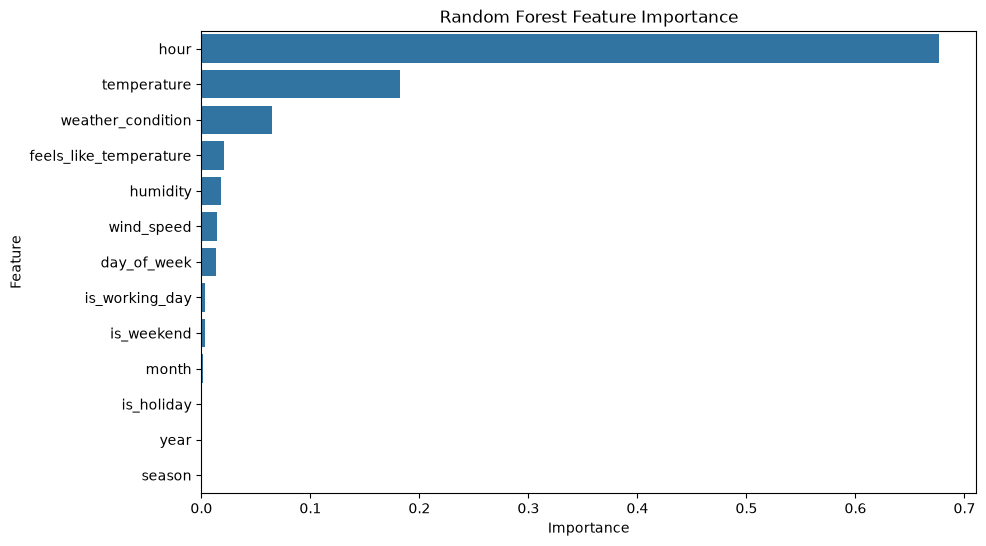

In [44]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

#display(feature_importance)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

***Step 13 — Actual vs Predicted Analysis***

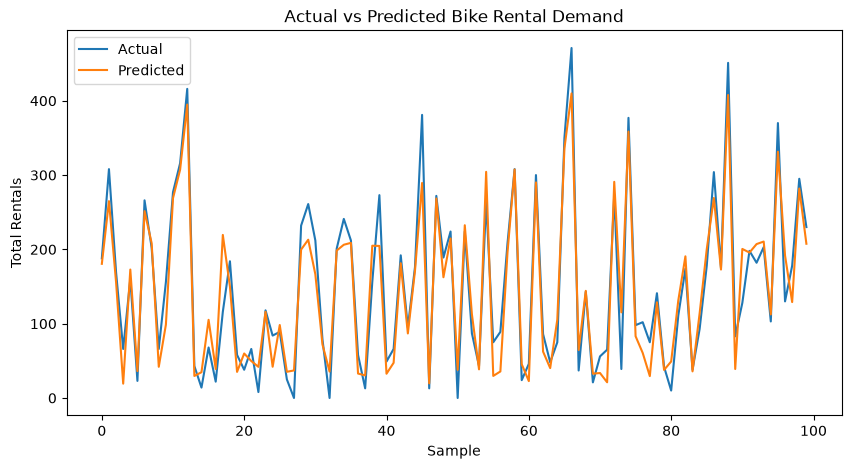

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(random_forest_prediction[:100], label="Predicted")

plt.title("Actual vs Predicted Bike Rental Demand")
plt.xlabel("Sample")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()